# 1D Allen-Cahn with EvoKAN-WF

- Problem:
  1D Allen-Cahn equation on $x \in [-1,1]$
- Governing equation:
  $$
  \partial_t u = \partial_{xx} u - \frac{1}{\varepsilon^2} u(u^2-1)
  $$
- Initial condition:
  $$
  u(x,0)=0.08\sin(\pi x)
  $$
- Boundary condition:
  $$
  u(-1,t)=u(1,t)=0
  $$
- Formulation:
  weak-form evolutionary KAN
- Workflow:
  fit the initial profile first, then project the residual onto test functions at each time step


In [109]:
import torch
import numpy as np
import random
import scipy

# --- Set a consistent random seed ---
seed = 5
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [110]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import *

class SplineLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, init_scale: float = 0.1, **kw) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)

class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis functions.
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        
        # Create the grid tensor and register it as a buffer
        grid_tensor = torch.linspace(grid_min, grid_max, num_grids)
        self.register_buffer('grid', grid_tensor)
        
        # If denominator is not given, compute the default value and register it as a buffer
        computed_denom = denominator if denominator is not None else (grid_max - grid_min) / (num_grids - 1)
        self.register_buffer('denominator', torch.tensor(computed_denom, dtype=grid_tensor.dtype))

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) * (x[..., None])


# class RadialBasisFunction(nn.Module):
#     def __init__(
#         self,
#         grid_min: float = -2.,
#         grid_max: float = 2.,
#         num_grids: int = 8,
#         denominator: float = None,  # larger denominators lead to smoother basis
#     ):
#         super().__init__()
#         self.grid_min = grid_min
#         self.grid_max = grid_max
#         self.num_grids = num_grids
#         self.grid = torch.linspace(grid_min, grid_max, num_grids)
#         #self.grid = torch.nn.Parameter(grid, requires_grad=False)
#         self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

#     def forward(self, x):
#         return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) * (x[..., None]**2)

class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim, bias=False)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [111]:
class FirstRadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        self.grid = torch.linspace(grid_min, grid_max, num_grids)
        #self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)
        
    def forward(self, x):
        # Move to the same device as x
        grid = self.grid.to(x.device)
        denominator = torch.tensor(self.denominator, dtype=x.dtype, device=x.device)
        return torch.exp(-((x[..., None] - grid) / denominator) ** 2) * (x[..., None]**2 - 1)
        
    # def forward(self, x):
    #     return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) * (x[..., None]**2 - 1)

class FastKANFirstLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = False,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = FirstRadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [112]:
class KAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_min: float = -1.,
        grid_max: float = 1.,
        num_grids: int = 4,
        use_base_update: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ):
        super(KAN, self).__init__()
        self.layers = torch.nn.ModuleList()


        self.layers.append(
                FastKANFirstLayer( ############### First layer
                    input_dim = 1,
                    output_dim = 3,
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=False,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )


        for in_features, out_features in zip(layers_hidden[1:], layers_hidden[2:]):
            self.layers.append(
                FastKANLayer( ################# rest
                    in_features,
                    out_features,
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=use_base_update,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )

    def forward(self, x: torch.Tensor, update_grid=False):
        #y = torch.clone(torch.hstack((torch.sin(torch.tensor(math.pi)*x), (torch.cos(torch.tensor(math.pi)*x) + 1))))
        y = torch.clone(x)
        for layer in self.layers:
            y = layer(y)
        return y

## Experiment Setup

- Random seed:
  `5`
- Spatial samples for the initial-condition fit:
  `num_of_x = 1001`
- Network:
  `KAN([1, 3, 3, 3, 3, 1])`
- Hidden-layer pattern:
  four hidden layers with width `3`
- Basis / activation:
  Gaussian RBF + `SiLU`
- Grid points per layer:
  `4`
- Initial-fit optimizer:
  `AdamW(lr=1e-3, weight_decay=1e-4)`
- Initial-fit epochs:
  `5001`
- Paper-aligned parameters:
  `epsilon = 0.002`, `delta_t = 1e-7`


In [113]:
import numpy as np
# Generate data
num_of_x = 1001 # 10001
grid_x = np.linspace(-1, 1, num_of_x)
grid_x = grid_x

In [114]:
f = np.zeros(shape=(num_of_x, ))

f = 0.08*np.sin(np.pi*grid_x)

x_input = np.zeros(shape=(num_of_x,))
f_input = np.zeros(shape=(num_of_x,))

for i in range(num_of_x):
  x_input[i] = grid_x[i]
  f_input[i] = f[i]

In [115]:
X_init = torch.tensor(x_input.reshape(-1,1), requires_grad=True).float()
y_init = torch.tensor(f_input.reshape(-1,1), requires_grad=True).float()

In [116]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define model
model = KAN([1, 3, 3, 3, 3, 1])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# Define loss
criterion = nn.MSELoss()

cuda


In [117]:
# Count trainable model parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 162


In [118]:
def train_step(model:torch.nn.Module,
               X_init,  y_init,
               epoch,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device=device):

  train_loss = 0

  # Put model into training mode
  model.train()

  # Put data on target device
  X_init, y_init= X_init.to(device), y_init.to(device)

  # 1. Forward pass
  y_init_pred = model(X_init)

  # 2. Calculate loss and metric
  loss_init = loss_fn(y_init_pred, y_init)

  loss = loss_init

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  # Print the loss
  train_loss = loss
  if epoch % 500 ==0:
    print(f"Train loss:{train_loss:.13f}")

In [119]:
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [120]:
# torch.manual_seed(1)

# Measure time
from tqdm.auto import tqdm
from timeit import default_timer as timer
start_time = timer()

# Set epochs
epochs = 5001

# Tarin the model
for epoch in tqdm(range(epochs)):
  if epoch % 500 == 0:
    print(f"Epoch:{epoch}\n----------")
  train_step(
      model = model,
      X_init = X_init,  y_init = y_init,
      epoch = epoch,
      loss_fn = criterion,
      optimizer = optimizer,
      device = device
  )

end_time = timer()
total_time = print_train_time(start = start_time, end = end_time, device = device)

  0%|          | 0/5001 [00:00<?, ?it/s]

Epoch:0
----------
Train loss:0.0031823953614
Epoch:500
----------
Train loss:0.0000004744576
Epoch:1000
----------
Train loss:0.0000002669277
Epoch:1500
----------
Train loss:0.0000001699520
Epoch:2000
----------
Train loss:0.0000001073671
Epoch:2500
----------
Train loss:0.0000000703294
Epoch:3000
----------
Train loss:0.0000000485008
Epoch:3500
----------
Train loss:0.0000000344950
Epoch:4000
----------
Train loss:0.0000000246232
Epoch:4500
----------
Train loss:0.0000000174944
Epoch:5000
----------
Train loss:0.0000000124838
Train time on cuda: 30.028 seconds


## Training Check

- Purpose:
  compare the fitted initial condition against the target profile
- Output:
  predicted $u(x,0)$ and reference $u(x,0)$ plots


In [121]:
# torch.manual_seed(42)
def eval_y(model: torch.nn.Module,
               X,
               loss_fn: torch.nn.Module,
               device = device):
  loss_res = 0
  model.eval()
  X = X.to(device)
  y_pred = model(X)

  return y_pred

In [122]:
y_init_pred = eval_y(model = model,
                     X = X_init,
                     loss_fn = criterion,
                     device = device)

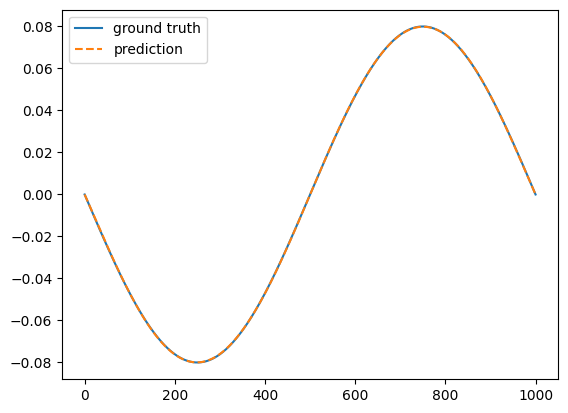

In [123]:
import matplotlib.pyplot as plt
plt.plot(y_init.to('cpu').detach().numpy(), label = 'ground truth')
plt.plot(y_init_pred.to('cpu').detach().numpy(), linestyle = '--', label = 'prediction')
plt.legend()

## Parameter Derivatives

- Goal:
  compute per-sample derivatives of the network output with respect to trainable parameters
- Tool:
  `torch.func` with `functional_call`, `grad`, and `vmap`
- Output:
  building blocks for strong-form and weak-form Jacobian assembly


In [124]:
from torch.func import functional_call, vmap, grad

def ft_compute_sample_grads(model, X_init):
    params = {k: v.detach() for k, v in model.named_parameters()}
    buffers = {k: v.detach() for k, v in model.named_buffers()}

    def predict(params, buffers, X_init):
        # prepend batch dimension for processing
        X_init = X_init.unsqueeze(0)
        X_init = X_init.to(device)

        prediction = functional_call(model, (params, buffers), (X_init))

        return prediction.squeeze()

    ft_compute_grad = grad(predict)
    ft_compute_sample_grad = vmap(ft_compute_grad, in_dims=(None, None, 0))
    ft_per_sample_grads = ft_compute_sample_grad(params, buffers, X_init)

    return ft_per_sample_grads


ft_per_sample_grads = ft_compute_sample_grads(model, X_init) # (n_layers, n_samples, out_dim, *)

In [125]:
print(len(ft_per_sample_grads))
print(ft_per_sample_grads.values)

9
<built-in method values of dict object at 0x763548e4d780>


In [126]:
print('num_layers: ', len(ft_per_sample_grads))
print('num_grads per sample: ', sum(g.shape[-2] * g.shape[-1] if len(g.shape) == 3 else g.shape[-1] for _, g in ft_per_sample_grads.items()))
# (n_layers, n_samples, out_dim, in_dim)
print(list(ft_per_sample_grads.values())[1].shape)

num_layers:  9
num_grads per sample:  162
torch.Size([1001, 3, 12])


## Jacobian Assembly

- Object:
  parameter Jacobian $J$
- Role:
  maps parameter perturbations to output perturbations
- Use:
  intermediate object before weak-form projection


In [127]:
W_origin = list(ft_per_sample_grads.values())
print(len(W_origin))
print(W_origin[0][0].shape)

9
torch.Size([3, 4])


In [128]:
def get_W_flatten(W_origin):
  W_flatten = []
  for i in range(len(W_origin)):
    W_flatten.append(torch.flatten(W_origin[i], start_dim=1))
  W_flatten_matrix = W_flatten[0]
  for i in range(1, len(W_origin)):
    W_flatten_matrix = torch.cat((W_flatten_matrix, W_flatten[i]), 1)
  return W_flatten_matrix

In [129]:
def compute_J():
  ft_per_sample_grads = ft_compute_sample_grads(model, X_init)
  W_origin = list(ft_per_sample_grads.values())
  #W_origin = compute_sample_grads(Allen_model, Coe_input, X_init)
  J = get_W_flatten(W_origin)
  return J

In [130]:
J = compute_J()
print(J.shape)

torch.Size([1001, 162])


In [131]:
# 1. Compute J
J = compute_J()
# Convert to a tensor if needed
if not torch.is_tensor(J):
    J = torch.from_numpy(J).float()
J = J.to(next(model.parameters()).device)  # align the device if needed
print("J shape:", J.shape)

# 2. Compute the condition number (strong form)
sv_J = torch.linalg.svdvals(J)  # singular values in descending order
# Exact condition number
cond_J = float("inf") if sv_J[-1] == 0 else (sv_J[0] / sv_J[-1]).item()
# Stabilized condition number (clamp the smallest singular value)
eps = 1e-12
cond_J_stable = (sv_J[0] / sv_J[-1].clamp_min(eps)).item()

print(f"cond(J) = {cond_J:.2e}, stabilized ≈ {cond_J_stable:.2e}")


J shape: torch.Size([1001, 162])
cond(J) = 4.35e+10, stabilized ≈ 4.35e+10


## Weak-Form Projection

- Weak form:
  multiply the PDE by a test function $v_k$ and integrate over the domain
- After integration by parts:
  $$
  \int_{-1}^1 \partial_t u \, v_k \, dx
  =
  -\int_{-1}^1 u_x (v_k)_x \, dx
  -
  \int_{-1}^1 \frac{1}{\varepsilon^2}u(u^2-1)v_k \, dx
  $$
- Boundary handling:
  boundary terms vanish because the test functions satisfy $v_k(\pm 1)=0$
- Numerical ingredients:
  Gauss-Legendre quadrature on $[-1,1]$, `N_quad = 64`, Fourier sine test functions


## Weak-Form $J$ Matrix and Quadrature

- Goal:
  evaluate the strong-form Jacobian at quadrature nodes and project it into the weak form
- Main ingredients:
  quadrature nodes, quadrature weights, and test-function matrix $V$
- Output:
  weak-form Jacobian $J_{\mathrm{weak}}$


In [132]:
from numpy.polynomial.legendre import leggauss
import numpy as np
import torch

# ─────────────────────────────────────────────────────────────────────
# 1) Gauss-Legendre quadrature for weak-form integration on [-1, 1]
#    Use enough quadrature nodes so cond(J_weak) does not grow excessively relative to the test space size.
N_quad   = 64
xi_ref, w_ref = leggauss(N_quad)
# No extra mapping is needed because the domain is already [-1, 1]
xi = xi_ref
w  = w_ref

# Convert to torch tensors
X_quad  = torch.tensor(xi.reshape(-1,1), requires_grad=True).float()  # [N_quad,1]
w_quad  = torch.tensor(w,               requires_grad=False).float()  # [N_quad]

# 2) Define Fourier sine test functions V[k, i]
#    phi_n(x) = sin(n*pi*(x+1)/2), n=1,...,K  (Dirichlet at x=-1,1)
#    A previous K=150 Legendre / N_quad=64 setup made high-order modes nearly linearly dependent,
#    which inflated the condition number of J_weak.
K        = 150
V_list   = []
for k in range(K):
    n = k + 1
    phi_n = np.sin(n * np.pi * (xi + 1.0) / 2.0)
    V_list.append(torch.tensor(phi_n, dtype=torch.float32))
V        = torch.stack(V_list, dim=0)                  # [K, N_quad]

In [133]:
# 3) Define a helper that evaluates the strong-form J at quadrature points
def compute_J_strong(X_points):
    """
    X_points: Tensor[N_pts, in_dim]
    returns : J_strong (Tensor[N_pts, P])
    """
    ft_per_sample_grads = ft_compute_sample_grads(model, X_points)
    W_origin            = list(ft_per_sample_grads.values())
    J                    = get_W_flatten(W_origin)      # [N_pts, P]
    # Convert to a tensor if the result is a NumPy array
    if isinstance(J, np.ndarray):
        J = torch.from_numpy(J).float()
    return J

# 4) Weak-form J assembly helper
def compute_J_weak(J, V, w):
    # 1) Apply quadrature weights: [N_quad, P]
    J_weighted = J * w.unsqueeze(1)
    # 2) Integrate against the test functions: [K, N_quad] @ [N_quad, P]
    J_weak     = V.matmul(J_weighted)
    return J_weak

# 5) Run the assembly
J_strong_quad = compute_J_strong(X_quad)               # [N_quad, P], often on cuda:0

# Move V and w_quad to the same device
device = J_strong_quad.device
V       = V.to(device)
w_quad  = w_quad.to(device)

# Device mismatch errors are avoided after this point.
J_weak  = compute_J_weak(J_strong_quad, V, w_quad)  # [K, P]
print(J_weak.shape)

torch.Size([150, 162])


In [134]:
# singular values
sv = torch.linalg.svdvals(J_weak)  # shape [min(K,P)]

# 1) Exact condition number (infinite if the smallest value is zero)
if sv[-1] == 0:
    cond_Jweak = float("inf")
else:
    cond_Jweak = (sv[0] / sv[-1]).item()

# 2) Stabilized condition number (clamp the smallest singular value with epsilon)
eps = 1e-12
cond_Jweak_stable = (sv[0] / sv[-1].clamp_min(eps)).item()

print(f"cond(J_weak) = {cond_Jweak:.2e}, stabilized ≈ {cond_Jweak_stable:.2e}")

cond(J_weak) = 1.09e+12, stabilized ≈ 5.86e+11


In [135]:
def change_to_np(list_vars):
  numpy_vars = []
  for i in range(len(list_vars)):
    numpy_vars.append(list_vars[i].cpu().detach().numpy())

  return numpy_vars

In [136]:
def store_parameter_size(list_vars):
  iter = len(list_vars)
  mat_size = []
  vec_size = []
  for i in range(iter):
    temp_vec = np.ndarray.flatten(list_vars[i], order='C')
    mat_size.append(list_vars[i].shape)
    vec_size.append(temp_vec.shape)
  return mat_size, vec_size

In [137]:
trainable_params = [param for param in model.parameters() if param.requires_grad]
np_vars = change_to_np(list(trainable_params))
mat_size, vec_size = store_parameter_size(np_vars)
print(mat_size)
print(vec_size)

[(3, 4), (3, 12), (3, 3), (3, 12), (3, 3), (3, 12), (3, 3), (1, 12), (1, 3)]
[(12,), (36,), (9,), (36,), (9,), (36,), (9,), (12,), (3,)]


In [138]:
def unfold_parameters(list_vars):
  mat_size, vec_size = store_parameter_size(list_vars)

  total_len = 0
  for i in range(len(vec_size)):
    total_len = total_len + vec_size[i][0]

  flat_vec = np.zeros(shape=(total_len,))
  iter = len(list_vars)
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    flat_vec[index:end_index] = np.ndarray.flatten(list_vars[i], order='C')
    index = index + vec_size[i][0]

  return flat_vec

In [139]:
def fold_vectors(vector, mat_size = mat_size, vec_size = vec_size):
  iter = len(mat_size)
  output_list = []
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    temp_mat = vector[index:end_index]
    output_list.append(np.reshape(temp_mat, newshape=mat_size[i], order='C'))
    index = index + vec_size[i][0]

  return output_list

In [140]:
flat_vec = unfold_parameters(np_vars)
print(len(flat_vec))
reconstruct_mat = fold_vectors(flat_vec, mat_size, vec_size)
print(len(reconstruct_mat))
print(reconstruct_mat[2].shape)

162
9
(3, 3)


## Spatial Derivatives

- Quantities:
  $u$, $u_x$, and $u_{xx}$
- Method:
  automatic differentiation with respect to $x$
- Use:
  residual and energy evaluation


In [141]:
# torch.manual_seed(42)
def Compute_x_gradient(model: torch.nn.Module,
                       X,
                       device = device):
  loss_res = 0
  model.eval()
  X = X.to(device)

  # 1. Forward pass
  y_pred = model(X)

  # 2. Calculate loss and metric

  y_x = torch.autograd.grad(
      y_pred, X,
      grad_outputs = torch.ones_like(y_pred),
      retain_graph = True,
      create_graph = True)[0]

  y_xx = torch.autograd.grad(
      y_x, X,
      grad_outputs = torch.ones_like(y_x),
      retain_graph = True,
      create_graph = True)[0]

  return y_pred, y_x, y_xx

In [142]:
u, u_x, u_xx = Compute_x_gradient(model, X_init)
u, u_x, u_xx = u.to("cpu").detach().numpy(), u_x.to("cpu").detach().numpy(), u_xx.to("cpu").detach().numpy()
print(u.shape)
print(u_x.shape)
print(u_xx.shape)

(1001, 1)
(1001, 1)
(1001, 1)


## Residual, Energy, and Time Marching

- Interface parameter:
  `epsilon = 0.002`
- Strong-form residual used before projection:
  $$
  N(u)=u_{xx}-\frac{1}{\varepsilon^2}u(u^2-1)
  $$
- Energy density:
  $$
  E(u,u_x)=\frac12 u_x^2 + \frac{(u^2-1)^2}{4\varepsilon^2}
  $$
- Time step:
  `delta_t = 1e-7`
- Number of steps:
  `500`
- Stored outputs:
  updated parameters, energy history, condition numbers, weak-form diagnostics, and checkpoints


## Compute $N$ and $E$

- Inputs:
  $u$, $u_x$, $u_{xx}$
- Outputs:
  residual $N(u)$ and energy density $E(u,u_x)$


In [143]:
def compute_N(u, u_x, u_xx):
  epsilon = 0.002
  N = u_xx - u * (u**2 - 1)/(epsilon**2)
  return N

## Compute Weak-Form Residual Vector

- Goal:
  project the pointwise residual onto the test space
- Discrete form:
  $$
  b_{\mathrm{weak}} \approx \eta \, V (w \odot N)
  $$
- Inputs:
  residual at quadrature nodes, test-function matrix, and quadrature weights


In [144]:
def compute_N_weak(N_quad, V, w, new_eta):
    """
    N_quad : Tensor[N_quad] — strong-form residual at quadrature points
    V      : Tensor[K, N_quad] — test function values v_k(x_i)
    w      : Tensor[N_quad]   — quadrature weights w_i
    new_eta: scalar           — scaling factor (eta)
    returns: b_weak (Tensor[K])
    """
    # Align devices
    device = V.device
    N_quad = N_quad.to(device)
    w      = w.to(device)
    
    # weighted residual: w_i * N_quad[i]
    weighted_N = w * N_quad               # [N_quad]
    
    # ∫ N(x) v_k(x) dx ≈ sum_i w_i N_quad[i] * V[k,i]
    # V.matmul(weighted_N) → [K, N_quad] @ [N_quad] → [K]
    N_weak = new_eta * V.matmul(weighted_N)
    return N_weak

In [145]:
def compute_E(u, u_x):
  epsilon = 0.002
  E = 0.5*(u_x**2) + (u**2 - 1)**2/(4*(epsilon**2))
  return E

In [146]:
def compute_r(energy, M, delta_t, previous_r):
  r = previous_r / (1 + delta_t*M/(2*energy))
  return r

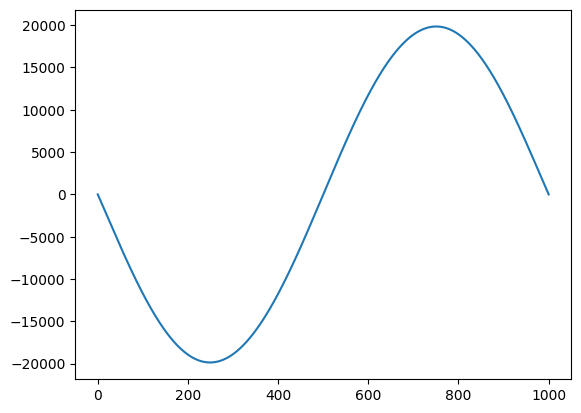

In [147]:
N_t = compute_N(u, u_x, u_xx)

plt.plot(N_t)

## Assign Parameters Back to the Model

- Goal:
  convert flattened parameter updates back into model tensors
- Use:
  restore checkpointed coefficients before evaluation or saving


In [148]:
def update_weights(new_vars):
  weights_tensor = []
  for i in range(len(new_vars)):
    weights_tensor.append(torch.tensor(new_vars[i]).float())

  trainable_params = [(name, param) for name, param in model.named_parameters() if param.requires_grad]
  for i, (name, param_tensor) in enumerate(trainable_params):
    model.state_dict()[name][:] = weights_tensor[i]

  '''
  for i, param_tensor in enumerate(model.state_dict()):
    model.state_dict()[param_tensor][:] = weights_tensor[i]
  '''

  return None

## Main Step

- Inputs:
  current time, step size, and previous auxiliary scalar
- Main tasks:
  assemble projected operators, solve the weak-form linearized system, and update parameters
- Outputs:
  next-step parameters, energy-related quantities, diagnostics, and timing information


In [149]:
import numpy as np
import torch
import scipy
import time as _time
from torch.nn.utils import parameters_to_vector, vector_to_parameters

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def _get_peak_mem_gb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024**3)
    return np.nan

def one_step_ahead(t_start, delta_t, previous_r, step_idx):
    breakdown = {"assemble": 0.0, "solve": 0.0, "total": 0.0}

    _sync_if_cuda()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    t0_total = _time.perf_counter()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ============================================================
    # (A) Matrix assembly START
    #     -> AD + (weak-form projection/quad) + J,b construction
    # ============================================================
    _sync_if_cuda(); t0_asm = _time.perf_counter()

    # ────────────────────────────────────────────────────────────
    # (A1) Collocation residual and energy/r (including AD)
    u0_t, u0_x_t, u0_xx_t = Compute_x_gradient(model, X_init)
    u0    = u0_t .detach().cpu().numpy().flatten()
    u0_x  = u0_x_t.detach().cpu().numpy().flatten()
    u0_xx = u0_xx_t.detach().cpu().numpy().flatten()

    N0 = compute_N(u0, u0_x, u0_xx)
    N0 = np.nan_to_num(N0, nan=0.0, posinf=1e6, neginf=-1e6)
    E  = compute_E(u0, u0_x)
    E  = np.nan_to_num(E, nan=0.0, posinf=1e6, neginf=-1e6)

    energy = E.mean()
    M      = (N0**2).mean()
    new_r  = compute_r(energy, M, delta_t, previous_r)
    new_eta= new_r / np.sqrt(energy)

    # ────────────────────────────────────────────────────────────
    # (A2) Assemble weak-form J (including AD, integration, and projection)
    J_strong_quad = compute_J_strong(X_quad).to(device)          # [N_quad,P]
    V_dev         = V.to(device)                                 # [K, N_quad]
    w_dev         = w_quad.to(device)                             # [N_quad]
    J_weak        = compute_J_weak(J_strong_quad, V_dev, w_dev)   # [K, P]
    J_np          = J_weak.detach().cpu().numpy().astype("float64")

    # (A3) cond(J): compute every 10 steps only (counted in matrix assembly)
    cond_J = np.nan
    if (step_idx % 10) == 0:
        S = np.linalg.svd(J_np, compute_uv=False)
        cond_J = (S[0] / S[-1]) if (S.size > 0 and S[-1] > 0) else np.inf

    # ────────────────────────────────────────────────────────────
    # (A4) Assemble b (including AD, integration, and projection)
    u_q_t, u_x_q_t, u_xx_q_t = Compute_x_gradient(model, X_quad)
    u_q    = u_q_t.  detach().cpu().numpy().flatten()
    u_x_q  = u_x_q_t.detach().cpu().numpy().flatten()
    u_xx_q = u_xx_q_t.detach().cpu().numpy().flatten()

    N_quad = compute_N(u_q, u_x_q, u_xx_q)
    N_quad = np.nan_to_num(N_quad, nan=0.0, posinf=1e6, neginf=-1e6)

    b_weak_t = compute_N_weak(
        torch.tensor(N_quad, device=device, dtype=torch.float32),
        V_dev, w_dev, new_eta
    )
    b_np = b_weak_t.detach().cpu().numpy().astype("float64")

    _sync_if_cuda(); t1_asm = _time.perf_counter()
    breakdown["assemble"] = (t1_asm - t0_asm)
    # ============================================================
    # (A) Matrix assembly END
    # ============================================================

    # ────────────────────────────────────────────────────────────
    # (B) solve (solve time)
    _sync_if_cuda(); t0 = _time.perf_counter()
    lsmr_maxiter = 2000
    lsmr_result = scipy.sparse.linalg.lsmr(J_np, b_np, maxiter=lsmr_maxiter)
    dw_dt = lsmr_result[0]
    lsmr_itn = lsmr_result[2]
    _sync_if_cuda(); t1 = _time.perf_counter()
    breakdown["solve"] = (t1 - t0)

    # ────────────────────────────────────────────────────────────
    # (C) Parameter update (included in total time)
    params   = [p for p in model.parameters() if p.requires_grad]
    w_tensor = parameters_to_vector(params).detach()
    new_w_t  = w_tensor + delta_t * torch.from_numpy(dw_dt).to(device).float()
    vector_to_parameters(new_w_t, params)

    _sync_if_cuda()
    breakdown["total"] = _time.perf_counter() - t0_total
    peak_mem_gb = _get_peak_mem_gb()

    return new_w_t.detach().cpu().numpy(), new_r, new_eta, energy, cond_J, breakdown, peak_mem_gb, lsmr_itn

In [150]:
E_0 = compute_E(u, u_x)
print(E_0.squeeze())
energy_0 = np.sum(E_0)/len(E_0)
r_0 = np.sqrt(energy_0)
print(r_0)

[62500.03  62500.    62499.914 ... 62499.914 62500.    62500.03 ]
249.20148198070297


In [151]:
# ─────────────────────────────────────────────────────────────────────
# Simulation loop: compute cond(J) every 10 steps and keep NaNs for skipped steps

import time as _time
import numpy as np

loop_start = _time.perf_counter()

t_start = 0.0
delta_t = 1e-7
steps   = 500

time_list        = []
energy_list      = []
r_list           = [r_0]
coefficient_list = []
condition_number = []  # cond(J); skipped steps keep NaN

# Optional storage for timing breakdown and peak memory
breakdown_list   = []
peakmem_list     = []
lsmr_iterations  = []

for i in range(steps):
    if i % 10 == 0:
        print(f"Step {i}")

    # Assume one_step_ahead computes cond_J only when step_idx % 10 == 0
    new_w, new_r, new_eta, new_energy, cond_J, breakdown, peak_mem_gb, lsmr_itn = one_step_ahead(
        t_start, delta_t, r_list[-1], step_idx=i
    )

    t_start += delta_t

    coefficient_list.append(new_w)
    time_list.append(t_start)
    r_list.append(new_r)
    energy_list.append(new_energy)
    condition_number.append(cond_J)  # skipped steps keep NaN

    breakdown_list.append(breakdown)
    peakmem_list.append(peak_mem_gb)
    lsmr_iterations.append(lsmr_itn)

loop_end = _time.perf_counter()
loop_elapsed = loop_end - loop_start
print(f"Final t_start: {t_start}")
print(f"Total loop time: {loop_elapsed:.4f} seconds")
print(f"Average time per step: {loop_elapsed / steps:.6f} seconds")
print("=== Elapsed Summary ===")
print(f"steps = {steps}")
print(f"delta_t = {delta_t:.1e}")
print(f"elapsed = {loop_elapsed:.4f} s")

# Inspect only computed cond(J) values (remove NaNs)
cond_arr = np.array(condition_number, dtype=float)
valid = np.isfinite(cond_arr)
print("Sample condition numbers (computed only):", cond_arr[valid][:10])

Step 0
Step 10
Step 20
Step 30
Step 40
Step 50
Step 60
Step 70
Step 80
Step 90
Step 100
Step 110
Step 120
Step 130
Step 140
Step 150
Step 160
Step 170
Step 180
Step 190
Step 200
Step 210
Step 220
Step 230
Step 240
Step 250
Step 260
Step 270
Step 280
Step 290
Step 300
Step 310
Step 320
Step 330
Step 340
Step 350
Step 360
Step 370
Step 380
Step 390
Step 400
Step 410
Step 420
Step 430
Step 440
Step 450
Step 460
Step 470
Step 480
Step 490
Final t_start: 5.0000000000000375e-05
Total loop time: 14.4207 seconds
Average time per step: 0.028841 seconds
=== Elapsed Summary ===
steps = 500
delta_t = 1.0e-07
elapsed = 14.4207 s
Sample condition numbers (computed only): [3.41538637e+10 4.29380400e+10 4.30574276e+10 2.52282191e+10
 4.02600573e+10 4.10491094e+10 2.79321091e+10 2.36235856e+10
 2.92431803e+10 2.19443011e+10]


In [152]:
print(condition_number)

[34153863730.1083, nan, nan, nan, nan, nan, nan, nan, nan, nan, 42938040020.08872, nan, nan, nan, nan, nan, nan, nan, nan, nan, 43057427577.511, nan, nan, nan, nan, nan, nan, nan, nan, nan, 25228219092.40514, nan, nan, nan, nan, nan, nan, nan, nan, nan, 40260057279.6233, nan, nan, nan, nan, nan, nan, nan, nan, nan, 41049109434.07067, nan, nan, nan, nan, nan, nan, nan, nan, nan, 27932109128.74854, nan, nan, nan, nan, nan, nan, nan, nan, nan, 23623585630.091507, nan, nan, nan, nan, nan, nan, nan, nan, nan, 29243180270.0244, nan, nan, nan, nan, nan, nan, nan, nan, nan, 21944301088.868057, nan, nan, nan, nan, nan, nan, nan, nan, nan, 33706024180.33247, nan, nan, nan, nan, nan, nan, nan, nan, nan, 21540967511.052547, nan, nan, nan, nan, nan, nan, nan, nan, nan, 15742259424.78603, nan, nan, nan, nan, nan, nan, nan, nan, nan, 27524997840.620678, nan, nan, nan, nan, nan, nan, nan, nan, nan, 22012783016.408035, nan, nan, nan, nan, nan, nan, nan, nan, nan, 19254187901.951572, nan, nan, nan, nan,

In [153]:
time_targets = [0.00, 0.00001, 0.00003, 0.00005]
# time_array = np.array(time)  # stored time history from the simulation
time_array = np.array(time_list)  # stored time history from the simulation
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]
print("Target time indices:", indices_to_update)

Target time indices: [0, 99, 299, 499]


In [154]:
# Target times: 50 multiples of 0.000001 starting from 0.000001
time_targets = [i * 0.000001 for i in range(1,51)]
# time_array = np.array(time)
time_array = np.array(time_list)
print(time_targets)

[1e-06, 2e-06, 3e-06, 4e-06, 4.9999999999999996e-06, 6e-06, 7e-06, 8e-06, 9e-06, 9.999999999999999e-06, 1.1e-05, 1.2e-05, 1.3e-05, 1.4e-05, 1.4999999999999999e-05, 1.6e-05, 1.7e-05, 1.8e-05, 1.8999999999999998e-05, 1.9999999999999998e-05, 2.1e-05, 2.2e-05, 2.3e-05, 2.4e-05, 2.4999999999999998e-05, 2.6e-05, 2.7e-05, 2.8e-05, 2.9e-05, 2.9999999999999997e-05, 3.1e-05, 3.2e-05, 3.2999999999999996e-05, 3.4e-05, 3.5e-05, 3.6e-05, 3.7e-05, 3.7999999999999995e-05, 3.9e-05, 3.9999999999999996e-05, 4.1e-05, 4.2e-05, 4.2999999999999995e-05, 4.4e-05, 4.4999999999999996e-05, 4.6e-05, 4.7e-05, 4.8e-05, 4.9e-05, 4.9999999999999996e-05]


In [155]:
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]
print(indices_to_update)

[9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199, 209, 219, 229, 239, 249, 259, 269, 279, 289, 299, 309, 319, 329, 339, 349, 359, 369, 379, 389, 399, 409, 419, 429, 439, 449, 459, 469, 479, 489, 499]


In [156]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================
# (2) Create the model save directory
# ============================
save_dir = "trained_model"
os.makedirs(save_dir, exist_ok=True)
print("Save directory:", save_dir)

# ============================
# (3) Update parameters and save the model
# ============================
# coefficient_list stores new_w from each time step
for i, idx in enumerate(indices_to_update):
    # Convert coefficient_list[idx] into model-shaped parameters with fold_vectors
    new_vars = fold_vectors(coefficient_list[idx])
    # Update model parameters using new_vars
    update_weights(new_vars)
    
    # Save the updated model checkpoint
    model_save_path = os.path.join(save_dir, f"RadialKAN_at_{time_targets[i]:.7f}.pt")
    torch.save(model.state_dict(), model_save_path)
    print(f"Save completion: {model_save_path}")


Save directory: trained_model
Save completion: trained_model/RadialKAN_at_0.0000010.pt
Save completion: trained_model/RadialKAN_at_0.0000020.pt
Save completion: trained_model/RadialKAN_at_0.0000030.pt
Save completion: trained_model/RadialKAN_at_0.0000040.pt
Save completion: trained_model/RadialKAN_at_0.0000050.pt
Save completion: trained_model/RadialKAN_at_0.0000060.pt
Save completion: trained_model/RadialKAN_at_0.0000070.pt
Save completion: trained_model/RadialKAN_at_0.0000080.pt
Save completion: trained_model/RadialKAN_at_0.0000090.pt
Save completion: trained_model/RadialKAN_at_0.0000100.pt
Save completion: trained_model/RadialKAN_at_0.0000110.pt
Save completion: trained_model/RadialKAN_at_0.0000120.pt


Save completion: trained_model/RadialKAN_at_0.0000130.pt
Save completion: trained_model/RadialKAN_at_0.0000140.pt
Save completion: trained_model/RadialKAN_at_0.0000150.pt
Save completion: trained_model/RadialKAN_at_0.0000160.pt
Save completion: trained_model/RadialKAN_at_0.0000170.pt
Save completion: trained_model/RadialKAN_at_0.0000180.pt
Save completion: trained_model/RadialKAN_at_0.0000190.pt
Save completion: trained_model/RadialKAN_at_0.0000200.pt
Save completion: trained_model/RadialKAN_at_0.0000210.pt
Save completion: trained_model/RadialKAN_at_0.0000220.pt
Save completion: trained_model/RadialKAN_at_0.0000230.pt
Save completion: trained_model/RadialKAN_at_0.0000240.pt
Save completion: trained_model/RadialKAN_at_0.0000250.pt
Save completion: trained_model/RadialKAN_at_0.0000260.pt
Save completion: trained_model/RadialKAN_at_0.0000270.pt
Save completion: trained_model/RadialKAN_at_0.0000280.pt
Save completion: trained_model/RadialKAN_at_0.0000290.pt
Save completion: trained_model/

In [157]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================
# (1) Choose target times and matching indices
# ============================
time_targets = [0.00, 0.00002, 0.00003, 0.00005]
time_array = np.array(time_list)  # stored time history from the simulation
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]
print("Target time indices:", indices_to_update)

# ============================
# (2) Create the model save directory
# ============================
save_dir = "trained_model"
os.makedirs(save_dir, exist_ok=True)
print("Save directory:", save_dir)

# ============================
# (3) Update parameters and save the model
# ============================
# coefficient_list stores new_w from each time step
for i, idx in enumerate(indices_to_update):
    # Convert coefficient_list[idx] into model-shaped parameters with fold_vectors
    new_vars = fold_vectors(coefficient_list[idx])
    # Update model parameters using new_vars
    update_weights(new_vars)
    
    # Save the updated model checkpoint
    model_save_path = os.path.join(save_dir, f"VBEKAN_at_{time_targets[i]:.5f}.pt")
    torch.save(model.state_dict(), model_save_path)
    print(f"Save completion: {model_save_path}")


Target time indices: [0, 199, 299, 499]
Save directory: trained_model
Save completion: trained_model/VBEKAN_at_0.00000.pt
Save completion: trained_model/VBEKAN_at_0.00002.pt
Save completion: trained_model/VBEKAN_at_0.00003.pt
Save completion: trained_model/VBEKAN_at_0.00005.pt


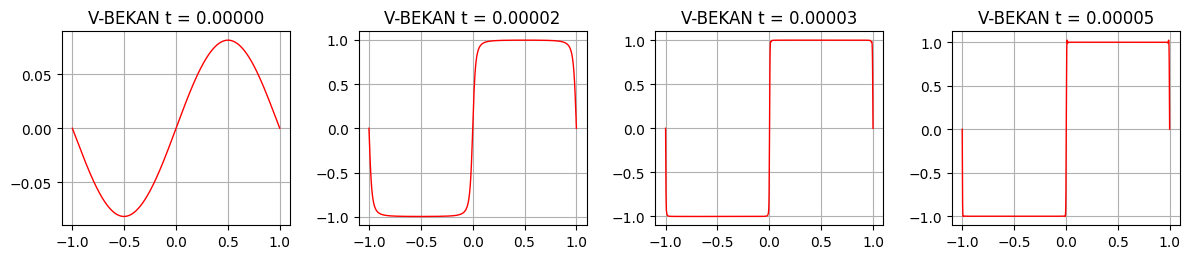

In [158]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Set device and X_init (with requires_grad enabled)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_init = torch.linspace(-1, 1, 1001).reshape(-1, 1).to(device).requires_grad_()

# Set the saved model directory and target times
save_dir = "trained_model"
time_targets = [0.00, 0.00002, 0.00003, 0.00005]

# Create a 1x4 subplot layout
fig, axes = plt.subplots(1, 4, figsize=(12, 2.7))
axes = axes.flatten()

for i, T in enumerate(time_targets):
    model_load_path = os.path.join(save_dir, f"VBEKAN_at_{T:.5f}.pt")
    
    # Load the model and switch to evaluation mode
    model.load_state_dict(torch.load(model_load_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    
    # Use Compute_x_gradient to evaluate test_u, test_u_x, and test_u_xx (only test_u is plotted here)
    test_u, test_u_x, test_u_xx = Compute_x_gradient(model, X_init)
    test_u = test_u.cpu().detach().numpy()
    
    # x coordinates as a NumPy array
    x_np = X_init.cpu().detach().numpy().flatten()
    
    # Plot test_u on the subplot
    ax = axes[i]
    ax.plot(x_np, test_u.flatten(), 'r-', linewidth=1)
    ax.set_title(f"V-BEKAN t = {T:.5f}")
    ax.grid(True)
    # ax.set_ylim(-1.3, 1.3)

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)  # create the results directory if needed
figure_save_path = os.path.join(results_dir, "VBEKAN_1D_Allen_Cahn.pdf")

plt.tight_layout()
plt.subplots_adjust(
    wspace=0.3, 
    hspace=0.4   
)
plt.savefig(figure_save_path, dpi=300, bbox_inches='tight')
plt.show()

In [159]:
import os
import numpy as np
import scipy.io as sio

save_dir = 'results/EvoKAN_weak_solution'
os.makedirs(save_dir, exist_ok=True)

# Multiples of 0.000001 from 1 to 50
time_targets = [i * 0.000001 for i in range(1, 51)]
time_array = np.array(time_list)
# time_array = np.array(time)

# Find the nearest indices
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]

for T, idx in zip(time_targets, indices_to_update):
    new_vars = fold_vectors(coefficient_list[idx])
    update_weights(new_vars)

    test_u, test_u_x, test_u_xx = Compute_x_gradient(model, X_init)

    test_u = test_u.cpu().detach().numpy().flatten()        # shape (N,)
    x_np   = X_init.cpu().detach().numpy().flatten()        # shape (N,)

    file_name = f"EvoKAN_WF_solution_at_{T:.6f}.mat"
    file_path = os.path.join(save_dir, file_name)

    sio.savemat(file_path, {
        'x': x_np.reshape(-1, 1),
        'u': test_u.reshape(-1, 1)
    })

    print(f"Saved solution for t = {T:.6f} at {file_path}")


Saved solution for t = 0.000001 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000001.mat
Saved solution for t = 0.000002 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000002.mat
Saved solution for t = 0.000003 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000003.mat
Saved solution for t = 0.000004 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000004.mat
Saved solution for t = 0.000005 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000005.mat
Saved solution for t = 0.000006 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000006.mat
Saved solution for t = 0.000007 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000007.mat
Saved solution for t = 0.000008 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000008.mat
Saved solution for t = 0.000009 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000009.mat
Saved solution for t = 0.000010 at results/EvoKAN_weak_solution/EvoKAN_WF_solution_at_0.000010.mat
Saved solu

In [160]:
i = 100  # selected step to inspect
print(f"""
Step {i}
---------
t            = {time_list[i]:.6e}
energy       = {energy_list[i]:.6e}
r            = {r_list[i]:.6e}
cond(J)      = {condition_number[i]}
assemble [s] = {breakdown_list[i]['assemble']:.4e}
solve    [s] = {breakdown_list[i]['solve']:.4e}
total    [s] = {breakdown_list[i]['total']:.4e}
peak mem [G] = {peakmem_list[i]:.4f}
""")



Step 100
---------
t            = 1.010000e-05
energy       = 3.412140e+04
r            = 1.855098e+02
cond(J)      = 33706024180.33247
assemble [s] = 2.1261e-02
solve    [s] = 2.9717e-03
total    [s] = 2.4540e-02
peak mem [G] = 0.0308



In [161]:
import numpy as np

def stats(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]  # remove NaNs
    return {
        "min":  np.min(arr),
        "max":  np.max(arr),
        "mean": np.mean(arr),
        "std":  np.std(arr),
    }

assemble_times = [b["assemble"] for b in breakdown_list]
solve_times    = [b["solve"]    for b in breakdown_list]
total_times    = [b["total"]    for b in breakdown_list]  # replace with total_lin if that is the intended metric
peak_mem       = peakmem_list
condJ          = condition_number
lsmr_iters     = lsmr_iterations

assemble_stats = stats(assemble_times)
solve_stats    = stats(solve_times)
total_stats    = stats(total_times)
mem_stats      = stats(peak_mem)
cond_stats     = stats(condJ)
lsmr_iter_stats = stats(lsmr_iters)

print("""
=== Per-step statistics over all time steps ===

[Assemble]
  min  = {amin:.4e} s
  max  = {amax:.4e} s
  mean = {amean:.4e} s
  std  = {astd:.4e} s

[Solve]
  min  = {smin:.4e} s
  max  = {smax:.4e} s
  mean = {smean:.4e} s
  std  = {sstd:.4e} s

[Total (linear system)]
  min  = {tmin:.4e} s
  max  = {tmax:.4e} s
  mean = {tmean:.4e} s
  std  = {tstd:.4e} s

[Peak memory]
  min  = {mmin:.4f} GB
  max  = {mmax:.4f} GB
  mean = {mmean:.4f} GB
  std  = {mstd:.4f} GB

[Condition number]
  min  = {cmin:.4e}
  max  = {cmax:.4e}
  mean = {cmean:.4e}
  std  = {cstd:.4e}

[LSMR iterations]
  min  = {imin:.4e}
  max  = {imax:.4e}
  mean = {imean:.4e}
  std  = {istd:.4e}
""".format(
    amin=assemble_stats["min"], amax=assemble_stats["max"],
    amean=assemble_stats["mean"], astd=assemble_stats["std"],
    smin=solve_stats["min"], smax=solve_stats["max"],
    smean=solve_stats["mean"], sstd=solve_stats["std"],
    tmin=total_stats["min"], tmax=total_stats["max"],
    tmean=total_stats["mean"], tstd=total_stats["std"],
    mmin=mem_stats["min"], mmax=mem_stats["max"],
    mmean=mem_stats["mean"], mstd=mem_stats["std"],
    cmin=cond_stats["min"], cmax=cond_stats["max"],
    cmean=cond_stats["mean"], cstd=cond_stats["std"],
    imin=lsmr_iter_stats["min"], imax=lsmr_iter_stats["max"],
    imean=lsmr_iter_stats["mean"], istd=lsmr_iter_stats["std"],
))


=== Per-step statistics over all time steps ===

[Assemble]
  min  = 1.8960e-02 s
  max  = 4.1381e-02 s
  mean = 1.9628e-02 s
  std  = 1.8406e-03 s

[Solve]
  min  = 1.4831e-03 s
  max  = 1.1651e-01 s
  mean = 8.1485e-03 s
  std  = 7.3012e-03 s

[Total (linear system)]
  min  = 2.0880e-02 s
  max  = 1.3715e-01 s
  mean = 2.8089e-02 s
  std  = 8.2068e-03 s

[Peak memory]
  min  = 0.0308 GB
  max  = 0.0308 GB
  mean = 0.0308 GB
  std  = 0.0000 GB

[Condition number]
  min  = 1.5742e+10
  max  = 4.1761e+11
  mean = 1.3614e+11
  std  = 1.2273e+11

[LSMR iterations]
  min  = 2.7000e+01
  max  = 2.4200e+02
  mean = 1.3092e+02
  std  = 5.7543e+01



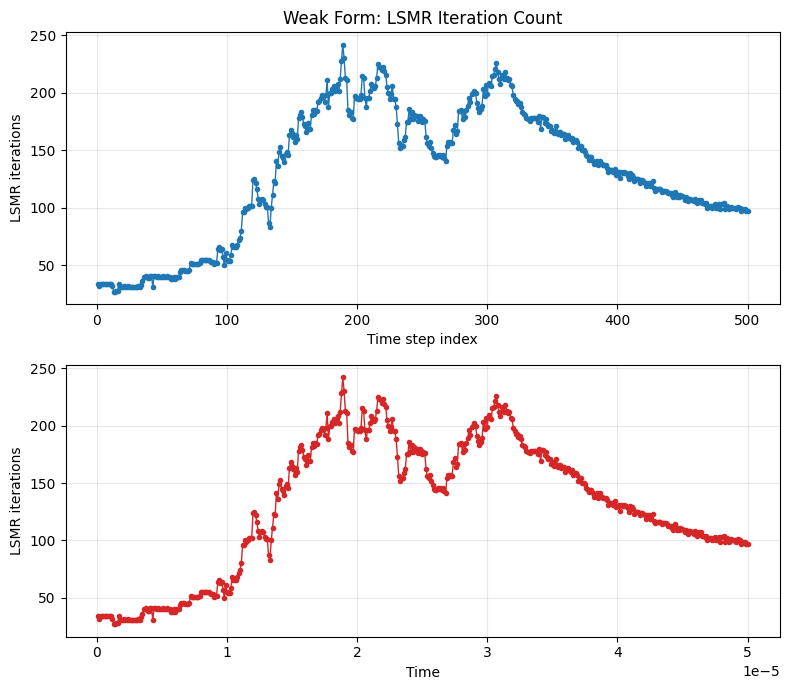

cwd: /home/user/bongseok
Saved figure to: results/lsmr_diagnostics/weak_lsmr_iteration_count.png
Figure exists: True
Saved LSMR iteration history to: results/lsmr_diagnostics/EvoKAN_weak_lsmr_iterations.mat
MAT exists: True


In [162]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

lsmr_iters = np.asarray(lsmr_iterations, dtype=float)
time_arr = np.asarray(time_list, dtype=float)
step_arr = np.arange(1, len(lsmr_iters) + 1)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharey=True)

axes[0].plot(step_arr, lsmr_iters, marker='o', markersize=3, linewidth=1)
axes[0].set_xlabel('Time step index')
axes[0].set_ylabel('LSMR iterations')
axes[0].set_title('Weak Form: LSMR Iteration Count')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_arr, lsmr_iters, marker='o', markersize=3, linewidth=1, color='tab:red')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('LSMR iterations')
axes[1].grid(True, alpha=0.3)

save_dir = 'results/lsmr_diagnostics'
os.makedirs(save_dir, exist_ok=True)
fig_path = os.path.join(save_dir, 'weak_lsmr_iteration_count.png')
mat_path = os.path.join(save_dir, 'EvoKAN_weak_lsmr_iterations.mat')

plt.tight_layout()
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

sio.savemat(
    mat_path,
    {
        'step': step_arr.reshape(-1, 1),
        'time': time_arr.reshape(-1, 1),
        'lsmr_iterations': lsmr_iters.reshape(-1, 1),
    }
)

print(f'cwd: {os.getcwd()}')
print(f'Saved figure to: {fig_path}')
print(f'Figure exists: {os.path.exists(fig_path)}')
print(f'Saved LSMR iteration history to: {mat_path}')
print(f'MAT exists: {os.path.exists(mat_path)}')
